## plot BEV (user-defined) vs. ICEV 

In [1]:
from utils.plot_mybev_vs_icev import *

In [2]:
import os
import xarray as xr
import sys
import itertools
from itertools import zip_longest
from lca_algebraic import initProject
import pandas as pd
import numpy as np
import xarray as xr
import pickle
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
plt.rcParams['font.family'] = 'Times New Roman'
plt.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid

In [3]:
with open('output/BEV_comb_final_pGWP_df_list.pkl', 'rb') as f:
    bev = pickle.load(f)

## 1. enter use input for BEV bat_tech

In [4]:
bat1, bat2 = user_define_bat_tech()

In [5]:
print(bat1.value, bat2.value)

LTO LSB


### choose the DF then plot according to the user input tech:

In [82]:
mybev = get_bev_df_per_input_tech(bev, bat1.value, bat2.value)
#mybev

index_number 6 from BEV dict for selected bat_tech


In [83]:
mybev2, icev2 = get_icev_map_bev_drop_nan(mybev, icev = pd.read_excel('output/ICEV_vlifecycle_finalLCA.xlsx')  ) 

/Users/susierwu/Dropbox/DLCA_DynCO2/pdpLCA_GT/notebooks/notebook_static_pLCA_vlifetime/v_combMod_pGWP100/utils/plot_mybev_vs_icev.py:81: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/susierwu/Dropbox/DLCA_DynCO2/pdpLCA_GT/notebooks/notebook_static_pLCA_vlifetime/v_combMod_pGWP100/utils/plot_mybev_vs_icev.py:82: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [84]:
df_list = prepare_concat_df_toplot(mybev2, icev2)

## plot 

#### DO NOT plot BEV with unavailable bat

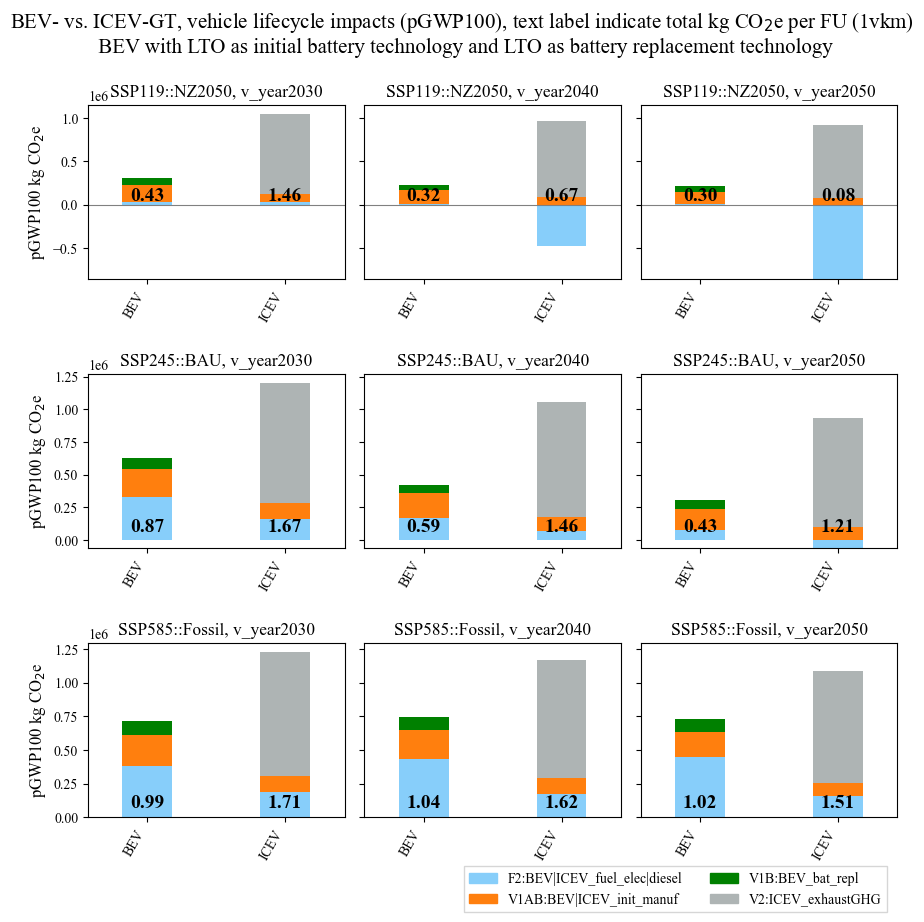

In [79]:
color_dict = {
    'F2':  'lightskyblue',   # 
    'V1AB': '#ff7f0e',  # Orange
    'V1B': 'green',   #green
    'V2': '#aeb4b4',   # Medium gray
}
FU = 20*36000

fig, axs = plt.subplots(3, 3, figsize=(9, 9), sharey='row')
axs = axs.flatten()

"""
### set up same decimal point for y-axis, not working 
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x:.1e}')
    ax.yaxis.set_major_formatter(formatter)
""" 

# different from static ICEV vs. BEV as now has user input, and we can't pre-control which subplots are blank (for LSB)
for i in range(len(df_list)) :
    ax = axs[i]
    
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    #ax.grid(True, linestyle='--', linewidth=0.5, color='gray')
    
    if len (df_list[i]) > 1:  # only plot BEV with avilable tech
        df = df_list[i]
        ddf = df[[ 'Powertrain', 'IC', 'V1AB', 'F2', 'V1B', 'V2']]  
        pivot_df = ddf.pivot_table(index='Powertrain', columns='IC', values= [ 'V1AB', 'F2', 'V1B', 'V2'  ] ) 
        colors = [color_dict[col[0]] for col in pivot_df.columns]
        pivot_df.plot(kind='bar', ax=ax, stacked=True, legend=False, color=colors, width=0.36, xlabel='' ) #title =subtitle
        
        # show text lable for lifecycle LCA score 
        columns_to_sum = ['V1AB', 'F2', 'V1B', 'V2']  
        bev_final_lca =  ddf[columns_to_sum].sum(axis=1).values[0] 
        icev_final_lca = ddf[columns_to_sum].sum(axis=1).values[1] 
        bev_lca_perfu = bev_final_lca / FU 
        icev_final_perfu = icev_final_lca / FU
        axs[i].text(0, 1e5, f'{bev_lca_perfu:.2f}', 
                    ha='center', va='center', fontsize=14, fontweight='bold', color='black')
        axs[i].text(1, 1e5, f'{icev_final_perfu:.2f}', 
                    ha='center', va='center', fontsize=14, fontweight='bold', color='black')
            # just set all x-label with available BEV
        axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=60, ha='right')
        #ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
        
    else:
        axs[i].text(0.5, 0.5, f'cannot build up your BEV \n based on bat_tech \n {bat1.value} and {bat2.value} combination', 
                    ha='center', va='center', fontsize=12, fontweight='bold', color='black')
        axs[i].set_xticklabels([])  
        axs[i].set_xlabel('') 
        
    # for ylables
    if i % 3 != 0:
        axs[i].set_ylabel('') 
    else: 
        axs[i].set_ylabel(r'pGWP100 kg CO$_2$e', fontsize = 12)

    # adding horizontal line for all SSP119 scenarios as there'll be negative diesel: 
    if i < 3:
        axs[i].axhline(y=0, color='gray', linewidth=0.8) 
        
    # hard-code subplot titles since there're df with nan SSP/Year value
    subt_size = 12.5
    axs[0].set_title("SSP119::NZ2050, v_year2030", fontsize=subt_size)
    axs[1].set_title("SSP119::NZ2050, v_year2040", fontsize=subt_size)
    axs[2].set_title("SSP119::NZ2050, v_year2050", fontsize=subt_size)
    axs[3].set_title("SSP245::BAU, v_year2030", fontsize=subt_size)
    axs[4].set_title("SSP245::BAU, v_year2040", fontsize=subt_size)
    axs[5].set_title("SSP245::BAU, v_year2050", fontsize=subt_size)
    axs[6].set_title("SSP585::Fossil, v_year2030", fontsize=subt_size)
    axs[7].set_title("SSP585::Fossil, v_year2040", fontsize=subt_size)
    axs[8].set_title("SSP585::Fossil, v_year2050", fontsize=subt_size)
    
# Add labels and title
tt =  f'BEV- vs. ICEV-GT, vehicle lifecycle impacts (pGWP100), text label indicate total kg CO$_2$e per FU (1vkm) \n BEV with {bat1.value} as initial battery technology and {bat2.value} as battery replacement technology'
fig.suptitle(tt, fontsize = 15)
handles = [mpatches.Patch(color=color_dict['F2'], label='F2:BEV|ICEV_fuel_elec|diesel'),
           mpatches.Patch(color=color_dict['V1AB'], label='V1AB:BEV|ICEV_init_manuf'),
           mpatches.Patch(color=color_dict['V1B'], label='V1B:BEV_bat_repl'),
           mpatches.Patch(color=color_dict['V2'], label='V2:ICEV_exhaustGHG') 
          ]
fig.legend(handles=handles, loc='lower right', bbox_to_anchor=(0.98, -0.03), fancybox=False, ncol=2)

f_name = 'output_plot/bev_' + f'{bat1.value}' + f'{bat2.value}' + "_vs_ICEV" + ".png"
fig.supxlabel('')
plt.tight_layout()
plt.show()
fig.savefig(f_name, bbox_inches='tight')

## plotly interactive 

### re-do the dataframe, filtering out non-available SSP/Year for HTML

plot same code other than  for annotation of text label on LC CO2e per vkm, as we don't know ahead what user-selected battery will be, we define row for add_annotation 

In [85]:
df =  pd.concat([mybev2, icev2], ignore_index=True)
df = df[df['IC'] == 'pGWP100']
columns_to_sum = ['V1AB', 'F2', 'V1B', 'V2']
df['LC_kgCO2e_vkm'] = round( df[columns_to_sum].sum(axis=1) / (36000*20) ,2)
#df.head()
#need to reindex dataframe, for plotly annotation subplot location
df.reset_index(drop=True, inplace=True)
df

,SSP,v_year,IC,V1AB,F2,V1B,Powertrain,V2,LC_kgCO2e_vkm
0,ssp119,2040,pGWP100,128014.377164,6377.565420,31623.702991,BEV,NaN,0.23
1,ssp119,2050,pGWP100,112523.797369,9669.330577,31674.283834,BEV,NaN,0.21
2,ssp245,2040,pGWP100,151278.599126,170015.279945,37941.003282,BEV,NaN,0.50
3,ssp245,2050,pGWP100,136205.974041,75600.105820,38182.661075,BEV,NaN,0.35
4,ssp119,2040,pGWP100,87556.976391,-480508.620881,NaN,ICEV,876671.642052,0.67
5,ssp119,2050,pGWP100,82663.226564,-858523.524094,NaN,ICEV,832677.228951,0.08
6,ssp245,2040,pGWP100,106102.075150,70081.143631,NaN,ICEV,877081.440251,1.46
7,ssp245,2050,pGWP100,99868.612059,-62909.048267,NaN,ICEV,833420.807008,1.21


In [54]:
tt1 = 'BEV- vs. ICEV-GT, vehicle lifecycle impacts (pGWP100), text label indicate total kg CO$_2$e per FU (1vkm)'
tt2 =  f'BEV with {bat1.value} as initial battery technology and {bat2.value} as battery replacement technology'
combined_title = f"{tt1}<br>{tt2}"
type(combined_title)

str

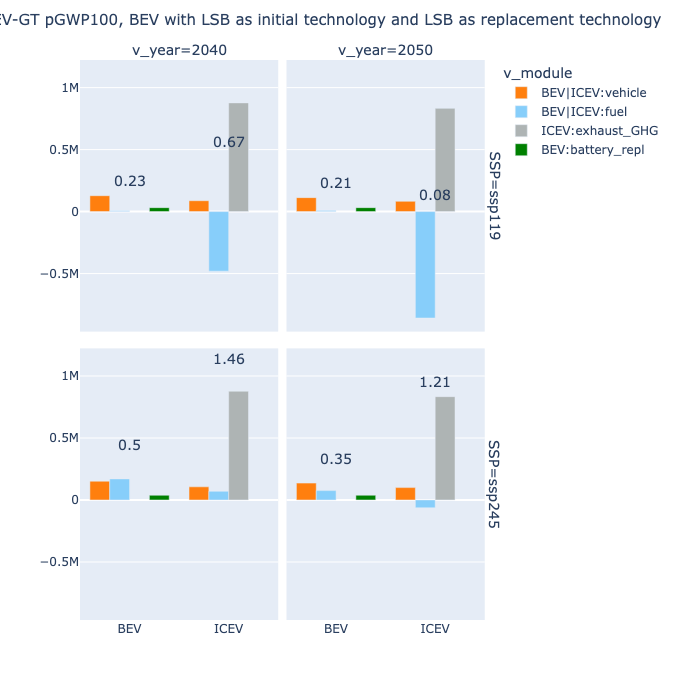

In [87]:
import plotly.express as px

tt1 = 'BEV- vs. ICEV-GT, vehicle lifecycle impacts (pGWP100), text label indicate total kg CO$_2$e per FU (1vkm)'
tt2 =  f'BEV with {bat1.value} as initial battery technology and {bat2.value} as battery replacement technology'
combined_title = f"{tt1}<br>{tt2}"
# can't do the combined_title, java error, below shorter oneline title works
tt =  f'BEV- vs. ICEV-GT pGWP100, BEV with {bat1.value} as initial technology and {bat2.value} as replacement technology'

color_dict = {
    'F2':  'lightskyblue',   # 
    'V1AB': '#ff7f0e',  # Orange
    'V1B': 'green',   #green
    'V2': '#aeb4b4',   # Medium gray
}

custom_labels = {
    'F2': 'BEV|ICEV:fuel',
    'V1AB': 'BEV|ICEV:vehicle',
    'V1B': 'BEV:battery_repl',
    'V2': 'ICEV:exhaust_GHG'
}

    
fig = px.bar(df, x="Powertrain", y= [ 'V1AB', 'F2', 'V2', 'V1B'],   
            #text='LC_kgCO2e_vkm' ,  # not working, using below annotation 
            barmode="group",   #stack,  if using stack, negative value on F2 messed up, tried with add_trace, not working
            color_discrete_map=color_dict,
            facet_row="SSP", facet_col="v_year"
            )


# to add text label on top of each bar (at location, y_sum)
for i in df.index:
    y_sum = df.loc[i, ['V1AB', 'F2', 'V2', 'V1B']].sum()
    x = df.loc[i, 'Powertrain']
    year = df.loc[i, 'v_year']
    ssp = df.loc[i, 'SSP']
    text = df.loc[i, 'LC_kgCO2e_vkm']
    # Determine the correct row and column based on 'v_year' and 'SSP'
    ### as we don't know ahead what user-selected battery will be, we define row for add_annotation here
    ### if use select both LSB for init and bat_replacment, then no year 2030 avail
    if 2030 in np.unique(df['v_year'].values):
        col = 1 if year == 2030 else 2 if year == 2040 else 3
    else:
        col = 1 if year == 2040 else 2  #only two rows, 2040 and 2050 
    
    if "ssp585" in np.unique(df['SSP'].values):
        row = 3 if ssp == 'ssp119' else 2 if ssp == 'ssp245' else 1
    else: 
        row = 2 if ssp == 'ssp119' else 1
    
    fig.add_annotation(x=x, y=y_sum, text=f'{text}',
                       showarrow=False,
                       xanchor='center',
                       yanchor='bottom',
                       row=row, col=col)

for trace in fig.data:
    trace.name = custom_labels[trace.name]

# Update layout 
fig.update_layout(    
    annotations=[dict(font_size=14)], 
    legend_title_text='v_module',
    title={
        'text': tt,
        'y': 0.98,  
        'x': 0.42,   # Center the title
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 15}  # Font size for tt1
    },
    width=900,  # Width of the entire figure in pixels
    height=700,  # Height of the entire figure in pixels
)

# do not use value as y-label , yaxis=dict(title='pGWP100 CO$_2$e') not working  will change whole plot format
fig.update_yaxes(title_text='', matches='y')
fig.update_xaxes(title_text='', matches='x')
#fig.update_layout(yaxis=dict(title='pGWP100 CO$_2$e'))

# Show the figure
fig.show()


f_name = 'output_plot/bev_' + f'{bat1.value}' + f'{bat2.value}' + "_vs_ICEV" + ".html"
fig.write_html(f_name)